# Correlated Brownian Motion

In the real world, asset prices don't move independently. When the market crashes, 
most stocks fall together. When oil prices rise, airline stocks tend to fall. 
**Correlated Brownian motion** captures this dependency.

## The Core Idea

Instead of one Brownian motion $W(t)$, we have a vector:

$$\mathbf{W}(t) = \begin{bmatrix} W_1(t) \\ W_2(t) \\ \vdots \\ W_n(t) \end{bmatrix}$$

Each component is a standard Brownian motion, but their **increments are correlated**:

$$\text{Corr}(\Delta W_i, \Delta W_j) = \rho_{ij}$$

## The Correlation Matrix

For $n$ assets, we define a symmetric positive-definite correlation matrix:

$$\Sigma = \begin{bmatrix} 
1 & \rho_{12} & \cdots & \rho_{1n} \\
\rho_{12} & 1 & \cdots & \rho_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\rho_{1n} & \rho_{2n} & \cdots & 1 
\end{bmatrix}$$

The covariance of increments is:

$$\text{Cov}(\Delta \mathbf{W}) = \Delta t \cdot \Sigma$$


## How to Generate Correlated Brownian Motion

We start with **independent** standard normals $\mathbf{Z} \sim \mathcal{N}(0, I)$ and 
transform them into correlated ones.

### Step 1: Cholesky Decomposition

Decompose the correlation matrix:

$$\Sigma = L \cdot L^T$$

where $L$ is a **lower triangular** matrix.

For a 2×2 case with correlation $\rho$:

$$\Sigma = \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix}$$

$$L = \begin{bmatrix} 1 & 0 \\ \rho & \sqrt{1-\rho^2} \end{bmatrix}$$

Verify: $L \cdot L^T = \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix}$ ✓

### Step 2: Generate Correlated Increments

$$\Delta \mathbf{W} = \sqrt{\Delta t} \cdot L \cdot \mathbf{Z}$$

### Why This Works

$$\text{Cov}(\Delta \mathbf{W}) = \Delta t \cdot L \cdot \underbrace{\text{Cov}(\mathbf{Z})}_{= I} \cdot L^T = \Delta t \cdot L \cdot L^T = \Delta t \cdot \Sigma$$

The correlation structure is perfectly preserved!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_correlated_bm(T=1.0, N=1000, n_paths=1, rho=0.0, seed=None):
    """
    Simulate 2D correlated Brownian motion.
    
    Parameters:
    -----------
    T : float
        Final time
    N : int
        Number of time steps
    n_paths : int
        Number of independent paths
    rho : float
        Correlation coefficient (-1 <= rho <= 1)
    seed : int or None
        Random seed for reproducibility
        
    Returns:
    --------
    t : ndarray, shape (N+1,)
        Time grid
    W : ndarray, shape (n_paths, 2, N+1)
        Correlated Brownian motion paths
    dW : ndarray, shape (n_paths, 2, N)
        Correlated increments
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Handle edge cases where Cholesky fails (singular matrix)
    if abs(rho - 1.0) < 1e-10:
        # Perfect positive correlation: W2 = W1
        dW1 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
        dW = np.stack([dW1, dW1], axis=1)
    elif abs(rho + 1.0) < 1e-10:
        # Perfect negative correlation: W2 = -W1
        dW1 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
        dW = np.stack([dW1, -dW1], axis=1)
    else:
        # General case: Cholesky decomposition
        corr = np.array([[1.0, rho], [rho, 1.0]])
        L = np.linalg.cholesky(corr)
        
        # Generate independent standard normals
        Z = np.random.normal(0, 1, size=(n_paths, 2, N))
        
        # Correlate them: dW = sqrt(dt) * L @ Z
        # einsum: 'ij,njk->nik' means matrix multiply L with each Z[n]
        dW = np.sqrt(dt) * np.einsum('ij,njk->nik', L, Z)
    
    # Cumulative sum to get W(t)
    W = np.zeros((n_paths, 2, N + 1))
    W[:, :, 1:] = np.cumsum(dW, axis=2)
    
    return t, W, dW

# Test it
t, W, dW = simulate_correlated_bm(T=1.0, N=1000, n_paths=3, rho=0.7, seed=42)
print(f"W shape: {W.shape}")
print(f"dW shape: {dW.shape}")
print(f"W(0): {W[:, :, 0]}")  # Should be [0, 0]


W shape: (3, 2, 1001)
dW shape: (3, 2, 1000)
W(0): [[0. 0.]
 [0. 0.]
 [0. 0.]]


## What Does Correlation Look Like?

| ρ | Visual Effect |
|---|---------------|
| **ρ = 0** | Paths move independently — one goes up, the other doesn't care |
| **ρ = 0.5** | Paths tend to move in the same direction, but not always |
| **ρ = 0.9** | Paths are very similar — when one rises, the other almost certainly rises |
| **ρ = -0.5** | Paths tend to move in opposite directions |
| **ρ = -0.9** | Paths are nearly mirror images |
| **ρ = +1** | Identical paths (W₂ = W₁) |
| **ρ = -1** | Mirror paths (W₂ = -W₁) |

> **Important:** Correlation affects the **increments**, not the levels directly. 
> Even with ρ = 0.9, W₁(t) and W₂(t) can diverge because they accumulate 
> independent noise over time.


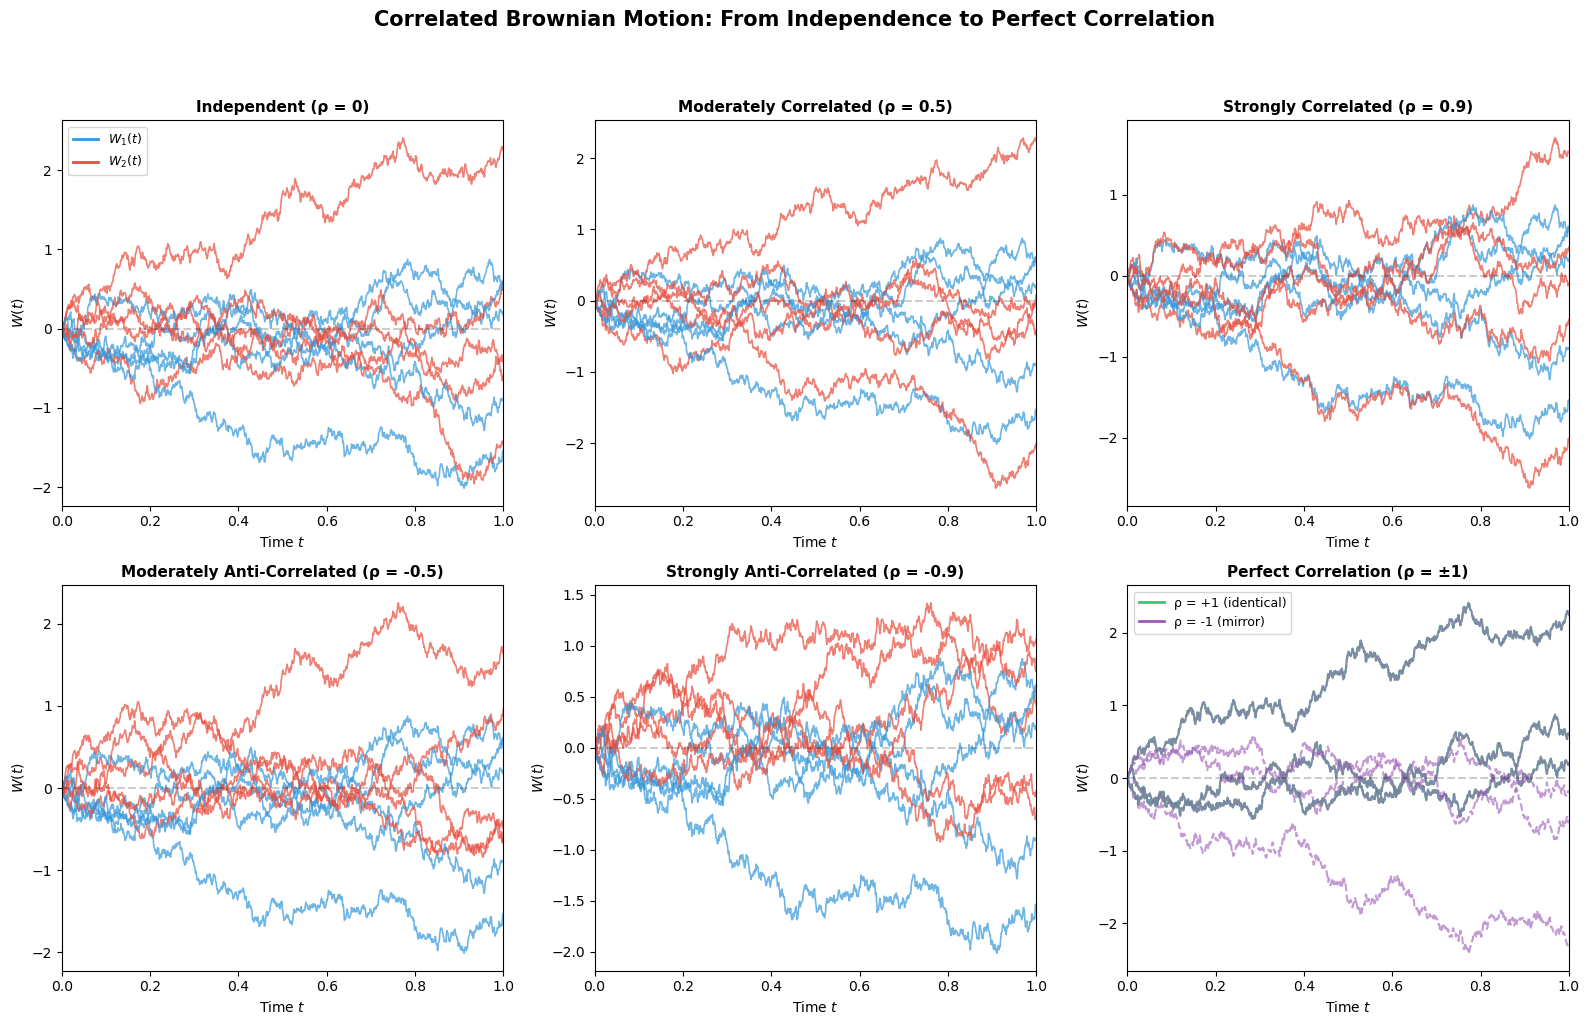

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Correlated Brownian Motion: From Independence to Perfect Correlation', 
             fontsize=15, fontweight='bold', y=1.02)

rhos = [0.0, 0.5, 0.9, -0.5, -0.9]
titles = ['Independent (ρ = 0)', 'Moderately Correlated (ρ = 0.5)', 
          'Strongly Correlated (ρ = 0.9)', 'Moderately Anti-Correlated (ρ = -0.5)',
          'Strongly Anti-Correlated (ρ = -0.9)']

for idx, (rho, title) in enumerate(zip(rhos, titles)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    t, W, dW = simulate_correlated_bm(T=1.0, N=1000, n_paths=5, rho=rho, seed=42)
    
    for i in range(5):
        ax.plot(t, W[i, 0], color='#3498db', alpha=0.7, linewidth=1.2)
        ax.plot(t, W[i, 1], color='#e74c3c', alpha=0.7, linewidth=1.2)
    
    if idx == 0:
        ax.plot([], [], color='#3498db', linewidth=2, label='$W_1(t)$')
        ax.plot([], [], color='#e74c3c', linewidth=2, label='$W_2(t)$')
        ax.legend(fontsize=9)
    
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time $t$', fontsize=10)
    ax.set_ylabel('$W(t)$', fontsize=10)
    ax.set_xlim(0, 1)

# Perfect correlation panel
ax = axes[1, 2]
t, W_pos, _ = simulate_correlated_bm(T=1.0, N=1000, n_paths=3, rho=1.0, seed=42)
t, W_neg, _ = simulate_correlated_bm(T=1.0, N=1000, n_paths=3, rho=-1.0, seed=42)

for i in range(3):
    ax.plot(t, W_pos[i, 0], color='#2ecc71', alpha=0.6, linewidth=1.5)
    ax.plot(t, W_pos[i, 1], color='#2ecc71', alpha=0.6, linewidth=1.5, linestyle='--')
    ax.plot(t, W_neg[i, 0], color='#9b59b6', alpha=0.6, linewidth=1.5)
    ax.plot(t, W_neg[i, 1], color='#9b59b6', alpha=0.6, linewidth=1.5, linestyle='--')

ax.plot([], [], color='#2ecc71', linewidth=2, label='ρ = +1 (identical)')
ax.plot([], [], color='#9b59b6', linewidth=2, label='ρ = -1 (mirror)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.2)
ax.set_title('Perfect Correlation (ρ = ±1)', fontsize=11, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=10)
ax.set_ylabel('$W(t)$', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## How to Verify the Correlation Structure

There are two levels of verification:

### 1. Increments Level (Instantaneous)
The increments $\Delta W_1$ and $\Delta W_2$ should have correlation $\rho$.

### 2. Process Level (Accumulated)
The processes $W_1(t)$ and $W_2(t)$ have covariance:

$$\text{Cov}(W_1(t), W_2(t)) = \rho \cdot t$$

This grows linearly with time! At $t=1$, the covariance equals $\rho$.


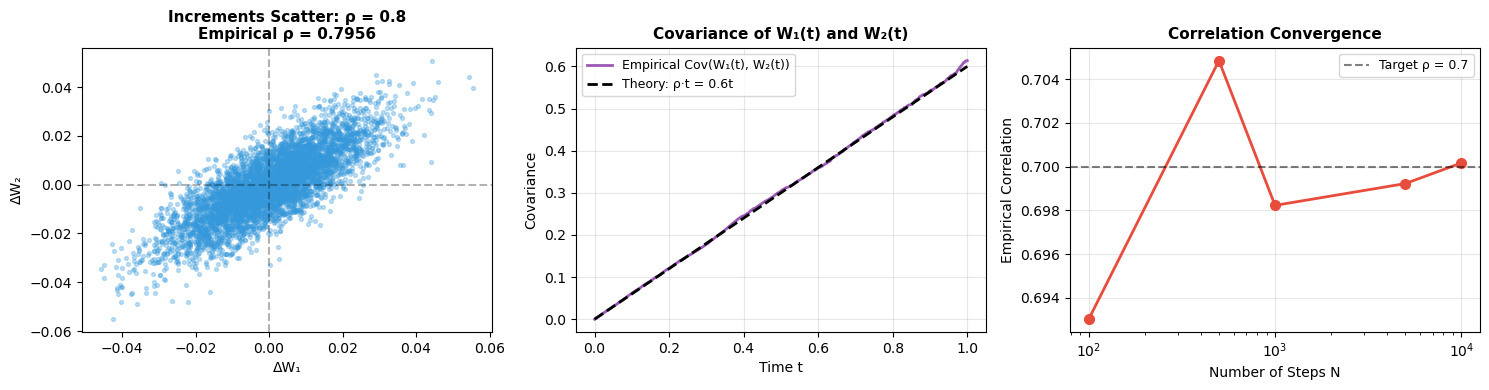

In [3]:
np.random.seed(2024)

# --- Verify increment correlation ---
t, W, dW = simulate_correlated_bm(T=1.0, N=5000, n_paths=1, rho=0.8, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter plot of increments
ax = axes[0]
ax.scatter(dW[0, 0, :], dW[0, 1, :], alpha=0.3, s=8, color='#3498db')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
emp_rho = np.corrcoef(dW[0, 0, :], dW[0, 1, :])[0, 1]
ax.set_title(f'Increments Scatter: ρ = 0.8\nEmpirical ρ = {emp_rho:.4f}', 
             fontsize=11, fontweight='bold')
ax.set_xlabel('ΔW₁')
ax.set_ylabel('ΔW₂')

# Verify covariance over time
ax = axes[1]
t, W_large, dW_large = simulate_correlated_bm(T=1.0, N=500, n_paths=10000, rho=0.6, seed=101)
cov_over_time = []
for j in range(W_large.shape[2]):
    cov = np.cov(W_large[:, 0, j], W_large[:, 1, j])[0, 1]
    cov_over_time.append(cov)

t_grid = np.linspace(0, 1, 501)
ax.plot(t_grid, cov_over_time, color='#9b59b6', linewidth=2, label='Empirical Cov(W₁(t), W₂(t))')
ax.plot(t_grid, 0.6 * t_grid, 'k--', linewidth=2, label='Theory: ρ·t = 0.6t')
ax.set_title('Covariance of W₁(t) and W₂(t)', fontsize=11, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Covariance')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Correlation convergence with sample size
ax = axes[2]
N_values = [100, 500, 1000, 5000, 10000]
emp_rhos = []
for N in N_values:
    t, W_test, dW_test = simulate_correlated_bm(T=1.0, N=N, n_paths=100, rho=0.7, seed=None)
    # Average correlation across paths
    rhos = [np.corrcoef(dW_test[p, 0, :], dW_test[p, 1, :])[0, 1] for p in range(100)]
    emp_rhos.append(np.mean(rhos))

ax.plot(N_values, emp_rhos, 'o-', color='#e74c3c', markersize=7, linewidth=2)
ax.axhline(y=0.7, color='black', linestyle='--', alpha=0.5, label='Target ρ = 0.7')
ax.set_title('Correlation Convergence', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Steps N')
ax.set_ylabel('Empirical Correlation')
ax.legend(fontsize=9)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Correlated Geometric Brownian Motion

For two stocks with correlated returns:

$$\frac{dS_1}{S_1} = \mu_1 \, dt + \sigma_1 \, dW_1$$

$$\frac{dS_2}{S_2} = \mu_2 \, dt + \sigma_2 \, dW_2$$

where $\text{Corr}(dW_1, dW_2) = \rho$.

### Exact Solutions

$$S_1(t) = S_1(0) \exp\left[\left(\mu_1 - \frac{\sigma_1^2}{2}\right)t + \sigma_1 W_1(t)\right]$$

$$S_2(t) = S_2(0) \exp\left[\left(\mu_2 - \frac{\sigma_2^2}{2}\right)t + \sigma_2 W_2(t)\right]$$

### Portfolio Variance

For a portfolio with weights $w_1$ and $w_2$:

$$\sigma_p^2 = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \rho \sigma_1 \sigma_2$$

### The Diversification Effect

| ρ | Portfolio σ (w₁=w₂=0.5, σ₁=20%, σ₂=25%) |
|---|------------------------------------------|
| -1.0 | 2.5% (minimum!) |
| -0.5 | 11.5% |
| 0.0 | 16.0% |
| +0.5 | 19.5% |
| +1.0 | 22.5% (maximum, no diversification) |

> **Key insight:** Negative correlation gives the best diversification. 
> With ρ = -1, you can theoretically eliminate ALL risk!


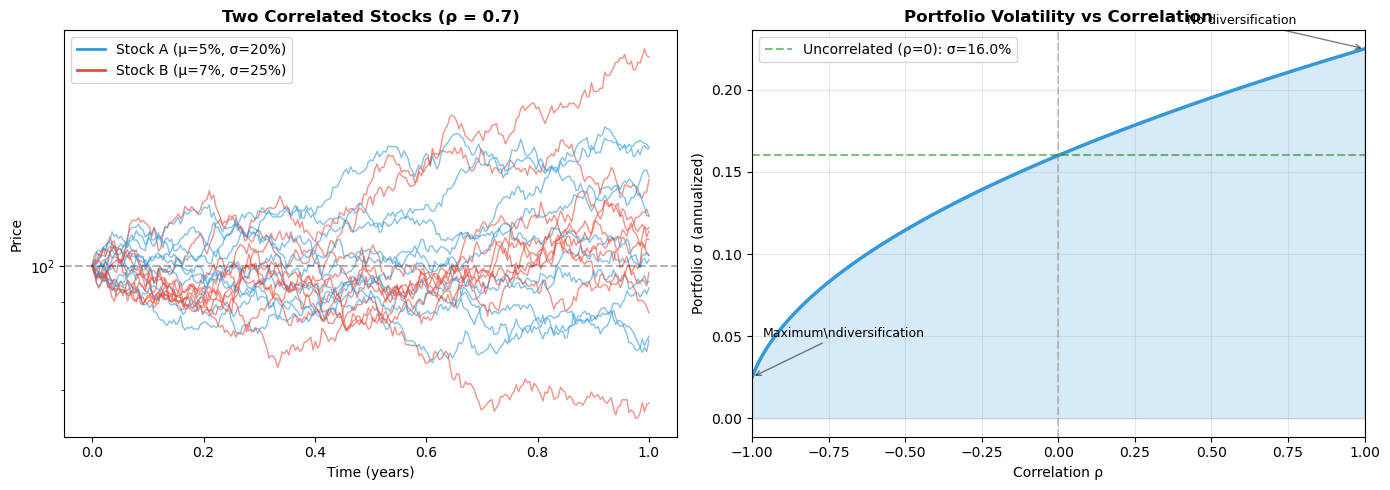

In [4]:
def simulate_correlated_gbm(S0=[100, 100], mu=[0.05, 0.07], sigma=[0.2, 0.25], 
                            rho=0.5, T=1.0, N=252, n_paths=1, seed=None):
    """
    Simulate two correlated GBM stock prices.
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate correlated Brownian increments
    if abs(rho - 1.0) < 1e-10:
        dW1 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
        dW = np.stack([dW1, dW1], axis=1)
    elif abs(rho + 1.0) < 1e-10:
        dW1 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
        dW = np.stack([dW1, -dW1], axis=1)
    else:
        corr = np.array([[1.0, rho], [rho, 1.0]])
        L = np.linalg.cholesky(corr)
        Z = np.random.normal(0, 1, size=(n_paths, 2, N))
        dW = np.sqrt(dt) * np.einsum('ij,njk->nik', L, Z)
    
    # GBM for each asset
    S = np.zeros((n_paths, 2, N + 1))
    S[:, :, 0] = S0
    
    for i in range(2):
        W = np.zeros((n_paths, N + 1))
        W[:, 1:] = np.cumsum(dW[:, i, :], axis=1)
        S[:, i, :] = S0[i] * np.exp((mu[i] - 0.5 * sigma[i]**2) * t + sigma[i] * W)
    
    return t, S, dW

# Simulate two correlated stocks
t, S, _ = simulate_correlated_gbm(S0=[100, 100], mu=[0.05, 0.07], 
                                   sigma=[0.2, 0.25], rho=0.7, 
                                   T=1.0, N=252, n_paths=10, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stock paths
ax = axes[0]
for i in range(10):
    ax.plot(t, S[i, 0, :], color='#3498db', alpha=0.6, linewidth=1)
    ax.plot(t, S[i, 1, :], color='#e74c3c', alpha=0.6, linewidth=1)
ax.plot([], [], color='#3498db', linewidth=2, label='Stock A (μ=5%, σ=20%)')
ax.plot([], [], color='#e74c3c', linewidth=2, label='Stock B (μ=7%, σ=25%)')
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3)
ax.set_title('Two Correlated Stocks (ρ = 0.7)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Price')
ax.legend(fontsize=10)
ax.set_yscale('log')

# Portfolio variance vs correlation
ax = axes[1]
rho_range = np.linspace(-1, 1, 200)
w1, w2 = 0.5, 0.5
sigma1, sigma2 = 0.2, 0.25

port_var = w1**2 * sigma1**2 + w2**2 * sigma2**2 + 2 * w1 * w2 * rho_range * sigma1 * sigma2
port_std = np.sqrt(port_var)

ax.plot(rho_range, port_std, color='#3498db', linewidth=2.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
uncorr_std = np.sqrt(w1**2 * sigma1**2 + w2**2 * sigma2**2)
ax.axhline(y=uncorr_std, color='green', linestyle='--', alpha=0.5, 
           label=f'Uncorrelated (ρ=0): σ={uncorr_std:.1%}')
ax.fill_between(rho_range, port_std, alpha=0.2, color='#3498db')
ax.set_title('Portfolio Volatility vs Correlation', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation ρ')
ax.set_ylabel('Portfolio σ (annualized)')
ax.set_xlim(-1, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate key points
ax.annotate('Maximum\\ndiversification', xy=(-1, port_std[0]), xytext=(-0.7, 0.05),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.5),
            fontsize=9, ha='center')
ax.annotate('No diversification', xy=(1, port_std[-1]), xytext=(0.6, 0.24),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.5),
            fontsize=9, ha='center')

plt.tight_layout()
plt.show()


## ⚠️ Common Bug: Reshaping Multi-Dimensional Arrays

When verifying correlation across many simulations, you might flatten the array like this:

```python
# WRONG! This mixes up components
all_dW = dW.reshape(n_sims * N, 3)
```

Numpy reshapes in C-order (last index varies fastest). For  dW  with shape   (n_sims, 2, N) , this creates rows like  [dW[0,0,0], dW[0,0,1], dW[0,0,2]]   — all from the same component!


# The Fix

Transpose first so that components are the last dimension:

# CORRECT: Components are preserved
all_dW = dW.transpose(0, 2, 1).reshape(n_sims * N, 3)


Now each row is  [dW1, dW2]  at one time step, and  np.corrcoef(all_dW.T)   gives the correct correlation matrix.



Cholesky matrix L:
[[1.         0.         0.        ]
 [0.8        0.6        0.        ]
 [0.3        0.43333333 0.84983659]]

Verification: L @ L.T
[[1.  0.8 0.3]
 [0.8 1.  0.5]
 [0.3 0.5 1. ]]

Target correlation matrix:
[[1.  0.8 0.3]
 [0.8 1.  0.5]
 [0.3 0.5 1. ]]

Empirical correlation matrix:
[[1.     0.8002 0.3005]
 [0.8002 1.     0.5001]
 [0.3005 0.5001 1.    ]]


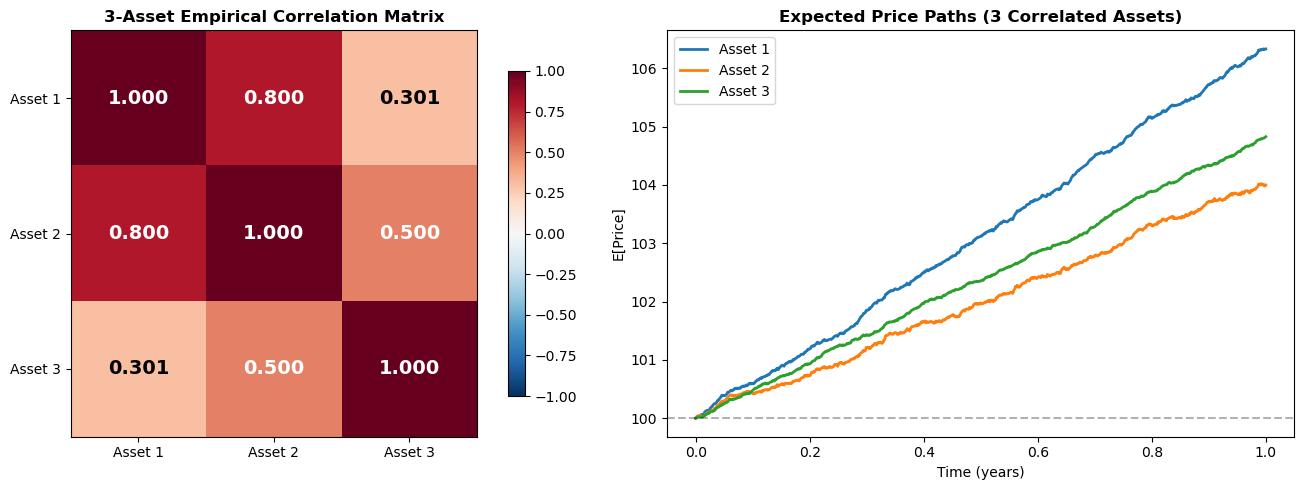

In [5]:
# 3-asset example with correlation matrix
np.random.seed(66)

corr_3 = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

L_3 = np.linalg.cholesky(corr_3)
print("Cholesky matrix L:")
print(L_3)
print("\nVerification: L @ L.T")
print(L_3 @ L_3.T)

# Simulate
N, n_sims = 1000, 5000
dt = 1.0 / N
Z = np.random.normal(0, 1, size=(n_sims, 3, N))
dW = np.sqrt(dt) * np.einsum('ij,njk->nik', L_3, Z)

# CORRECT reshape for correlation verification
all_dW = dW.transpose(0, 2, 1).reshape(n_sims * N, 3)
emp_corr = np.corrcoef(all_dW.T)

print("\nTarget correlation matrix:")
print(corr_3)
print("\nEmpirical correlation matrix:")
print(np.round(emp_corr, 4))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(emp_corr, cmap='RdBu_r', vmin=-1, vmax=1, extent=[-0.5, 2.5, 2.5, -0.5])
labels = ['Asset 1', 'Asset 2', 'Asset 3']
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{emp_corr[i,j]:.3f}', ha='center', va='center', 
                fontsize=14, fontweight='bold',
                color='white' if abs(emp_corr[i,j]) > 0.5 else 'black')
ax.set_title('3-Asset Empirical Correlation Matrix', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Simulate correlated GBM prices for 3 assets
ax = axes[1]
S0 = [100, 100, 100]
mu = [0.06, 0.04, 0.05]
sigma = [0.2, 0.25, 0.15]

S = np.zeros((n_sims, 3, N + 1))
S[:, :, 0] = S0
t = np.linspace(0, 1, N + 1)

for i in range(3):
    W = np.zeros((n_sims, N + 1))
    W[:, 1:] = np.cumsum(dW[:, i, :], axis=1)
    S[:, i, :] = S0[i] * np.exp((mu[i] - 0.5 * sigma[i]**2) * t + sigma[i] * W)

# Plot mean paths
for i in range(3):
    ax.plot(t, np.mean(S[:, i, :], axis=0), linewidth=2, label=f'Asset {i+1}')
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3)
ax.set_title('Expected Price Paths (3 Correlated Assets)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('E[Price]')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Where Correlated Brownian Motion Is Used

| Application | Why Correlation Matters |
|-------------|------------------------|
| **Portfolio optimization** | Diversification depends on correlations |
| **Basket options** | Payoff depends on multiple correlated assets |
| **Spread options** | Price difference between two correlated assets |
| **Credit derivatives** | Default correlation between firms |
| **Foreign exchange** | Currency pairs are often correlated |
| **Interest rate models** | Multiple rates (short, long) move together |
| **Stochastic volatility** | Heston model correlates price and volatility |

## Extensions to Explore

1. **Time-varying correlation** — $\rho(t)$ changes over time (DCC-GARCH models)
2. **Factor models** — $n$ assets driven by $k < n$ factors
3. **Copulas** — More flexible dependency structures than correlation
4. **Stochastic correlation** — $\rho$ itself follows a stochastic process
5. 

|  Concept  |  Formula  |
|-----------|-----------|
|  Cholesky (2×2)  |  $L = \begin{bmatrix} 1 & 0 \\ \rho & \sqrt{1-\rho^2} \end{bmatrix}$  |
|  Correlated increments  |  $\Delta \mathbf{W} = \sqrt{\Delta t} \cdot L \cdot \mathbf{Z}$  |
|  Covariance of increments  |  $\text{Cov}(\Delta \mathbf{W}) = \Delta t \cdot \Sigma$  |
|  Covariance of processes  |  $\text{Cov}(W_i(t), W_j(t)) = \rho{ij} \cdot t$  |
|  Portfolio variance (2 assets)  |  $\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1w_2\rho\sigma_1\sigma_2$  |	
